# imports 


In [1]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
import joblib
import os
import json
import pickle
import pandas as pd 
import numpy as np 
from CustomTranformers.Custom_Transf import Preprocces \
, FullImputer , preproccesBeforePipe , try_diffrient_classification_models \
, GetDiffrentClassifiers , getting_counts ,getting_lat_long,get_best_match ,get_closest_address

In [2]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, \
                            recall_score, f1_score, \
                            roc_auc_score, roc_curve, \
                            confusion_matrix , auc

In [3]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier

In [4]:
data = pd.read_csv('data/train.csv')

In [5]:
data['Date'].iloc[0]

'2020-12-01T01:10:00+00:00'

# data range of dates

In [ ]:
cop = data.copy()
cop['Date'] = pd.to_datetime(cop['Date'],infer_datetime_format=True)
cop['Date'].min() , cop['Date'].max()

# preproccesing before training 

In [6]:
df_model = preproccesBeforePipe(data,train=True)

In [7]:
# df_model.to_csv('data/df_model.csv',index = False)

In [8]:
# df_model = pd.read_csv('data/df_model.csv')

# splitting the data and making stratify 

In [9]:
X_train, X_test= train_test_split(df_model,
        test_size = .2 ,random_state=42, stratify=df_model['target'])

# making all data as training

In [10]:
       
X_trainAll , y_trainAll = df_model.drop('target',axis = 1) , df_model[['observation_id','target']]

In [11]:
# X_trainAll.to_csv('data/X_trainAll.csv',index = False)
# y_trainAll.to_csv('data/y_trainAll.csv',index = False)

# saving the data files

In [12]:
# X_train.to_csv('data/X_train.csv',index = False)
# y_train.to_csv('data/y_train.csv',index = False)
# X_test.to_csv('data/X_test.csv',index = False)
# y_test.to_csv('data/y_test.csv',index = False)

# Read Training and test data

In [13]:
# X_train = pd.read_csv('data/X_train.csv')
# y_train = pd.read_csv('data/y_train.csv')
# X_test = pd.read_csv('data/X_test.csv')
# y_test = pd.read_csv('data/y_test.csv')

In [14]:
# X_train = pd.read_csv('data/low/X_trainLow.csv')
# y_train = pd.read_csv('data/low/y_trainLow.csv')
# X_test = pd.read_csv('data/low/X_testLow.csv')
# y_test = pd.read_csv('data/low/y_testLow.csv')

# checking distribution of target

# check if legislation and object of search are the same 

In [15]:
# dc ={}
# for x in X_train['Legislation'].unique().tolist():
#     print(x)
#     object_search = X_train[X_train['Legislation'] == x]['Object of search']
#     if object_search.empty:
#         print('No corresponding values in "Object of search"')
#     else:
#         most_frequent = object_search.value_counts().idxmax()
#         if isinstance(most_frequent, float) and pd.isna(most_frequent):
#             print('Most frequent value is NaN')
#         else:
#             dc[x] = most_frequent
            
#     print('___________________________________________________________')
# with open('pickles/legmap.json', 'w') as fh:
#     json.dump(dc, fh)

In [16]:
# with open(os.path.join('pickles', 'legmap.json')) as fh:
#             mapping =  json.load(fh)
# X_train['legislation_category'] = X_train['Legislation'].map(mapping)

# # Check if 'legislation_category' and 'object of search' columns match
# X_train['same_category'] = X_train['legislation_category'] == X_train['Object of search']

# Read all data

In [17]:
# X_trainAll = pd.read_csv('data/X_trainAll.csv')
# y_trainAll = pd.read_csv('data/y_trainAll.csv')

In [18]:
# y_trainAll['target'].value_counts(normalize=True)

# making Custom transformers

In [19]:
# They are in the custom_trnaf file 

In [20]:
# class Preprocces(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         return None

#     def fit(self, X, y=None):
#         # Fit the transformer and store it.
#         return self
        
#     def transform(self, X):
#         df_model= X.copy()
# #         df_model = df_model.set_index('observation_id')
#         # feature engineering from Date 
#         df_model['Date'] = pd.to_datetime(df_model['Date'],infer_datetime_format=True)
#         df_model['day_of_week'] = df_model['Date'].dt.day_name()
#         df_model['month'] = df_model['Date'].dt.month
#         df_model['hour'] = df_model['Date'].dt.hour
#         df_model['year'] = df_model['Date'].dt.year
#         df_model.drop(columns = ['Date','observation_id'],inplace=True)
#         return df_model

In [21]:
# class FullImputer(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         return None

#     def fit(self, X, y=None):
#         data = X.copy()
#         # Fit the transformer and store it.
#         self.pipe = joblib.load('pickles/pipeline_legislation.pickle')
#         self.mapping = {}
#         for name, group in data.groupby("station")[['Latitude','Longitude']]:
#             try :
                
#                 self.mapping [name] = group.mode().iloc[0].to_dict()  
#             except IndexError : 
#                 continue
#         return self
        
#     def transform(self, X):
#         data = X.copy()
# #         # filling outcome linked
# #         data.loc[:,'Outcome linked to object of search'].fillna(False,inplace = True)
#         # filling part of policing operation
#         data['Part of a policing operation'].fillna(False,inplace = True)
#         # filling legislation 
#         test = data.loc[data['Legislation'].isnull(),['Legislation','Object of search']]
#         pred =  self.pipe.predict(test[['Object of search']])
#         data.loc[data['Legislation'].isnull(),'Legislation'] = pred
#         # filling lat and long 
#         for name, group in data.groupby("station")[['Latitude','Longitude']]:
#             try :
#                 idxs = group.index
#                 if group['Latitude'].isnull().sum() : 
#                     imputer_lat = SimpleImputer(strategy="constant",fill_value = self.mapping[name]['Latitude'])
#                     data.loc[idxs,['Latitude']] = imputer_lat.fit_transform(group[['Latitude']])
#                 if group['Longitude'].isnull().sum() :
#                     imputer_long = SimpleImputer(strategy="constant",fill_value = self.mapping[name]['Longitude'])
#                     data.loc[idxs,['Longitude']] = imputer_long.fit_transform(group[['Longitude']])
#             except KeyError :
#                 coordinate = getting_lat_long(name)
#                 for key , value in coordinate.items():
#                     imputer_fail = SimpleImputer(strategy='constant',fill_value=value)
#                     data.loc[idxs,[key]] = imputer_fail.fit_transform(group[[key]])
                
#         return data

# getting numerical and categorical features

In [22]:
# proccesor = Preprocces()
# imputer = FullImputer()
# temp = imputer.fit_transform(proccesor.fit_transform(X_train))
# numerical_features = list(temp.select_dtypes(['float64','int64']).columns)
# categorical_features = list(temp.select_dtypes(['bool','object']).columns)
# print(numerical_features)
# print(categorical_features)
numerical_features = ['Latitude', 'Longitude', 'month', 'hour', 'year']
categorical_features = ['Type', 'Part of a policing operation', 'Gender', 'Age range', 'Officer-defined ethnicity', 'Legislation', 'Object of search', 'station','is_holiday','Timeofday','DayofWeek','pastmid']

# make Holidays dates as feature engineering 

In [23]:
# from datetime import date
# import json 
# holiday_years = range(2020, 2024)
# holiday_dates = []
# # Generate combined holiday dates
# holiday_dates += [
#     date(year, 1, 1) for year in holiday_years  # Good Friday
# ] + [
#     date(year, 12, 25) for year in holiday_years  # Good Friday
# ] + [
#     date(year, 4, 14) for year in holiday_years  # Good Friday
# ] +  [
#     date(year, 4, 17) for year in holiday_years  # Easter Monday
# ] + [
#     date(year, 5, 1) for year in holiday_years   # Early May Bank Holiday
# ] + [
#     date(year, 5, 29) for year in holiday_years  # Spring Bank Holiday
# ] + [
#     date(year, 8, 28) for year in holiday_years  # Summer Bank Holiday
# ] + [
#     date(year, 12, 26) for year in holiday_years # Boxing Day
# ] + [
#     date(year, 12, 27) for year in holiday_years # Additional Holiday (substitute for Christmas Day)
# ]

# holiday_dates = [dt.isoformat() for dt in holiday_dates]

# # Save holiday dates to JSON file
# with open('pickles/holidays.json', 'w') as fh:
#     json.dump(holiday_dates, fh)

# feature engineering with date 

In [24]:
# from datetime import date
 
# class Preprocces(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         return None

#     def fit(self, X, y=None):
#         # Fit the transformer and store it.
#         return self
        
#     def transform(self, X):
#         df_model= X.copy()
# #         df_model = df_model.set_index('observation_id')
#         df_model['Date'] = pd.to_datetime(df_model['Date'],infer_datetime_format=True)
#         df_model['month'] = df_model['Date'].dt.month
#         df_model['hour'] = df_model['Date'].dt.hour
#         df_model['year'] = df_model['Date'].dt.year
#         with open(os.path.join('pickles', 'holidays.json')) as fh:
#             holiday_dates =  json.load(fh)
#         df_model['is_holiday'] = df_model['Date'].apply(lambda x : 1 if x.date() in holiday_dates else 0)
#         time_bins = [0, 6, 9, 12, 16, 20, 24]
#         time_labels = ['night', 'early morning', 'morning', 'mid-afternoon', 'evening', 'late evening']
#         df_model['Timeofday'] = pd.cut(df_model['hour'], bins=time_bins, labels=time_labels)
#         df_model['DayofWeek'] = df_model['Date'].dt.day_name()
#         df_model['afterMidNight'] = (df_model['Date'].dt.hour <6 ).astype(int)
#         # Season
#         df_model['season'] = pd.cut(df_model['month'], bins=[0, 3, 6, 9, 12], labels=['winter', 'spring', 'summer', 'autumn'])

#         # Quarter
#         df_model['quarter'] = pd.to_datetime(df_model['Date']).dt.quarter

#         # Weekday/Weekend
#         df_model['is_weekend'] = df_model['Date'].dt.dayofweek.isin([5, 6]).astype(int)

#         # Day/Night
#         df_model['is_daytime'] = df_model['Timeofday'].isin(['morning', 'afternoon']).astype(int)
#                 # feature engineering from Date 
        
# #         df_model['day_of_week'] = df_model['Date'].dt.day_name()
        
#         df_model.drop(columns = ['Date','observation_id'],inplace=True)
#         return df_model


# making the full pipeline 

In [25]:

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('onehot', ce.one_hot.OneHotEncoder(handle_unknown='indicator',use_cat_names=True))])

Dealer = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])
Pipe = Pipeline([
    ('preprocces',Preprocces()),
    ('imputer',FullImputer())
    ,('dealer',Dealer)
    ,('model',GradientBoostingClassifier(learning_rate=0.2, max_depth=6, min_samples_leaf=4,
                           min_samples_split=12, n_estimators=400,random_state=42))
#     ,('model',LGBMClassifier(learning_rate=0.3, n_estimators=600,
#                                 random_state=42))
#      ('model',
#                  LGBMClassifier(learning_rate=0.3, n_estimators=600,
#                                 num_leaves=63, random_state=42))
])


In [26]:
new_data = pd.read_csv('data/new_data.csv').drop('predicted_outcome',axis = 1)
new_data

,observation_id,Type,Date,Part of a policing operation,Latitude,Longitude,Gender,Age range,Officer-defined ethnicity,Legislation,Object of search,station,outcome
0,1558a55e-3df2-4665-8beb-0f0c5eaa0408,Person search,2022-04-06T18:25:00+00:00,True,NaN,NaN,Male,10-17,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,nottinghamshire,False
1,eeb891e3-3913-4590-82a9-dc23c212dceb,Person search,2022-04-18T22:24:57+00:00,NaN,NaN,NaN,Male,10-17,Other,Police and Criminal Evidence Act 1984 (section 1),Articles for use in criminal damage,city-of-london,True
2,898d6606-c55b-4a54-9480-f967beaff1cf,Person and Vehicle search,2022-01-07T20:20:00+00:00,True,NaN,NaN,Male,25-34,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,nottinghamshire,False
3,3ff08b3c-c1fc-4c9f-97fe-470cf3a61cef,Person search,2022-05-08T20:21:00+00:00,True,NaN,NaN,Male,over 34,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,nottinghamshire,False
4,73d7c589-7605-42ab-9c5c-d0fbb897adb0,Person search,2022-02-12T01:43:00+00:00,NaN,54.525683,-1.556382,Male,over 34,White,Police and Criminal Evidence Act 1984 (section 1),Article for use in theft,durham,False


In [34]:
new_data['Date']

0       2022-04-06T18:25:00+00:00
1       2022-04-18T22:24:57+00:00
2       2022-01-07T20:20:00+00:00
3       2022-05-08T20:21:00+00:00
4       2022-02-12T01:43:00+00:00
                  ...            
4015    2022-03-13T02:45:00+00:00
4016    2022-03-13T15:45:00+00:00
4017    2022-03-13T23:24:00+00:00
4018    2022-03-14T03:22:00+00:00
4019    2022-03-14T14:20:00+00:00
Name: Date, Length: 4020, dtype: object

In [27]:
old_data = df_model.copy()
old_data.rename(columns={'target':'outcome'},inplace=True)
old_data.head()

,observation_id,Type,Date,Part of a policing operation,Latitude,Longitude,Gender,Age range,Officer-defined ethnicity,Legislation,Object of search,station,outcome
0,2e4d0094-c30b-471b-a211-72a9790feca2,person search,2020-12-01T01:10:00+00:00,NaN,50.798824,-1.089471,male,25-34,white,police and criminal evidence act 1984 (section 1),article for use in theft,hampshire,True
1,4779fbe8-6e05-4534-85fd-db32952ee309,person search,2020-12-01T02:00:00+00:00,NaN,50.785099,-1.091540,male,over 34,other,misuse of drugs act 1971 (section 23),controlled drugs,hampshire,False
2,cb5c685d-acac-42e2-914d-75e6ff73b0a8,person search,2020-12-01T09:15:00+00:00,NaN,50.952006,-1.403341,male,over 34,white,misuse of drugs act 1971 (section 23),controlled drugs,hampshire,False
3,f486e116-5b1e-45db-9931-a7f070c5c478,person search,2020-12-01T10:20:00+00:00,NaN,50.806383,-1.079844,male,10-17,white,police and criminal evidence act 1984 (section 1),stolen goods,hampshire,False
4,78f4020e-12cc-4889-bf1a-2f2c29b2f662,person search,2020-12-01T10:24:00+00:00,NaN,50.806670,-1.081982,male,10-17,asian,police and criminal evidence act 1984 (section 1),offensive weapons,hampshire,False


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming you have a DataFrame called 'old_data' containing the old data
# and a DataFrame called 'new_data' containing the new data

# Add a column 'is_new' to indicate if the observation belongs to the new data
old_data['is_new'] = 0
new_data['is_new'] = 1

# Concatenate the old and new data
combined_data = pd.concat([old_data, new_data], ignore_index=True)

# Split the combined data into train and test sets while maintaining the class distribution
train_data, test_data = train_test_split(combined_data, test_size=0.2,random_state=42, stratify=combined_data['is_new'])

# Remove the 'is_new' column from the train and test sets
train_data = train_data.drop('is_new', axis=1)
test_data = test_data.drop('is_new', axis=1)

In [35]:
train_data.isnull().sum()

observation_id                       0
Type                                 0
Date                                 0
Part of a policing operation    156832
Latitude                         78892
Longitude                        78892
Gender                               0
Age range                            0
Officer-defined ethnicity            0
Legislation                      31862
Object of search                     0
station                              0
outcome                              0
dtype: int64

# training Display model

In [ ]:
# Pipe = Pipeline([
#     ('preprocces',Preprocces()),
#     ('imputer',FullImputer())
#     ,('dealer',Dealer)
# ])
# Pipe.fit(X_train)
# # temp = Pipe.transform(X_train)
# # temp = Pipe.transform(X_test)
# # joblib.dump(Pipe, 'pickles/pipes/display_pipetry.pickle') 

# loading the display model 

In [ ]:
# Pipe = joblib.load('pickles/pipes/display_pipe2.pickle')

# Display transformation to check Transformers work

In [ ]:
# temp = Pipe.transform(X_train)
# encoded_cols = Pipe['dealer'].named_transformers_['cat']['onehot'].get_feature_names()
# df = pd.DataFrame(temp,columns=numerical_features+encoded_cols)
# df

# check learning curve

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.model_selection import learning_curve
# from sklearn.metrics import make_scorer
# def plot_learning_curve(estimator, X, y, train_sizes, cv):
#     avg_precision_scorer = make_scorer(average_precision_score, greater_is_better=True)
#     train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, train_sizes=train_sizes, cv=cv,scoring=avg_precision_scorer)
    
#     # Calculate mean and standard deviation of train and test scores
#     train_mean = np.mean(train_scores, axis=1)
#     train_std = np.std(train_scores, axis=1)
#     test_mean = np.mean(test_scores, axis=1)
#     test_std = np.std(test_scores, axis=1)
    
#     # Plot learning curves
#     plt.figure(figsize=(8, 6))
#     plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training accuracy')
#     plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
#     plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation accuracy')
#     plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
    
#     # Add labels and title
#     plt.xlabel('Training Examples')
#     plt.ylabel('Accuracy')
#     plt.title('Learning Curves')
#     plt.legend(loc='lower right')
#     plt.grid(True)
#     plt.show()
# train_sizes = np.linspace(0.1, 1.0, 10)
# cv = 5  # 5-fold cross-validation
# plot_learning_curve(Pipe,X_train,y_train['target'],train_sizes,cv)

# Fitting the model and pickle

In [ ]:
cop = train_data.copy()
cop['Date'] = pd.to_datetime(cop['Date'],infer_datetime_format=True,utc = True)
cop.set_index('Date',inplace=True)
cop.loc['May 2022']

In [36]:
Pipe.fit(train_data.drop('outcome',axis = 1),train_data['outcome'])
# play_tune()
# joblib.dump(Pipe, 'pickles/try/try.pickle') 

Pipeline(steps=[('preprocces', Preprocces()), ('imputer', FullImputer()),
                ('dealer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'Longitude',
                                                   'month', 'hour', 'year']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='indicator',
                                                                                 use_cat_names=True))]),
                                                  ['Type',
                                                   'Part of a policing '
                                                   'operation',
                                                   'Gender', 'Age range',
                                                   'Officer-defined ethnicity',
                                                   'Legislation',
                                                   'Object of search',
                                                   'station', 'is_holiday',
                                                   'Timeofday', 'DayofWeek',
                                                   'pastmid'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.2, max_depth=6,
                                            min_samples_leaf=4,
                                            min_samples_split=12,
                                            n_estimators=400,
                                            random_state=42))])

In [37]:
joblib.dump(Pipe, 'pickles/try/retrain.pickle') 

['pickles/try/retrain.pickle']

# Loading the model 

In [ ]:
Pipe = joblib.load('pickles/try/best_GBC.pickle')

### number of features used

In [38]:
Pipe.named_steps['model'].n_features_in_

145

# predictions with some evaluation matrix

In [41]:
X_test = test_data.drop('outcome',axis =1 )
y_test = test_data['outcome']

In [42]:
pred_proba = Pipe.predict_proba(X_test)[:, 1]

In [43]:
av = average_precision_score(y_test,pred_proba)
ra = roc_auc_score(y_test,pred_proba)
print(f'Average precision : {av}')
print(f'ROC AUC score : {ra}')

Average precision : 0.39453797494135
ROC AUC score : 0.6498359677209335


# getting best threshold

recall : 0.6500409574952216
precision : 0.3550848932309146
threshold : 0.2589091068323581
f1 score : 0.4592852204948474


/tmp/ipykernel_5433/1617971730.py:24: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax1.get_shared_x_axes().join(ax1, ax2,ax3)


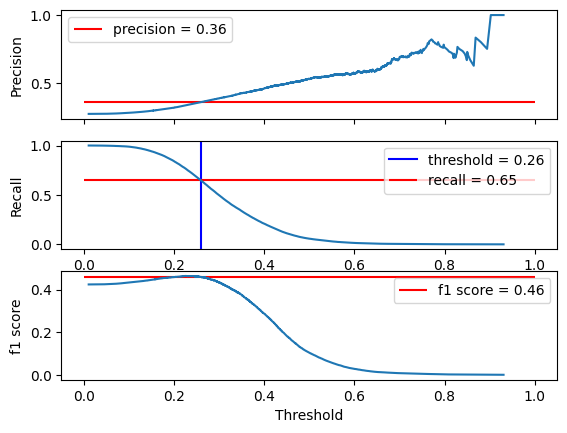

In [52]:
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
precision = precision[:-1]
recall = recall[:-1]
f1_scores = 2*(precision*recall)/(precision + recall)
maxf = max(f1_scores)
min_index = [i for i, rec in enumerate(recall) if rec >= 0.65][-1]
print(f'recall : {recall[min_index]}')
print(f'precision : {precision[min_index]}')
print(f'threshold : {thresholds[min_index]}')
print(f'f1 score : {f1_scores[min_index]}')
fig=plt.figure()
ax1 = plt.subplot(311)
ax2 = plt.subplot(312)
ax3 = plt.subplot(313)
ax1.hlines(y=precision[min_index],xmin=0, xmax=1, colors='red', label=f'precision = {precision[min_index]:.2f}')
ax2.axvline(thresholds[min_index], color='blue', label=f'threshold = {thresholds[min_index]:.2f}')
ax2.hlines(y=recall[min_index],xmin=0, xmax=1, colors='red', label=f'recall = {recall[min_index]:.2f}')
ax3.hlines(y=f1_scores[min_index],xmin=0, xmax=1, colors='red', label=f'f1 score = {f1_scores[min_index]:.2f}')
ax1.plot(thresholds,precision)
ax2.plot(thresholds,recall)
ax3.plot(thresholds,f1_scores)
ax1.get_shared_x_axes().join(ax1, ax2,ax3)
ax1.set_xticklabels([])
ax1.set_ylabel('Precision')
ax2.set_ylabel('Recall')
ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')
ax3.set_ylabel('f1 score')
plt.xlabel('Threshold')
plt.show()


In [53]:
threshold =  0.2589091068323581
preds = [1 if pred > threshold else 0 for pred in pred_proba ]

In [54]:
# precision = precision_score(y_true=y_test['target'], y_pred=preds)
# recall = recall_score(y_true=y_test['target'], y_pred=preds)
# f1 = f1_score(y_true=y_test['target'], y_pred=preds)
# print(f'precision = {precision}')
# print(f'recall = {recall}')
# print("F1 score:", f1)

# Evaluate model 

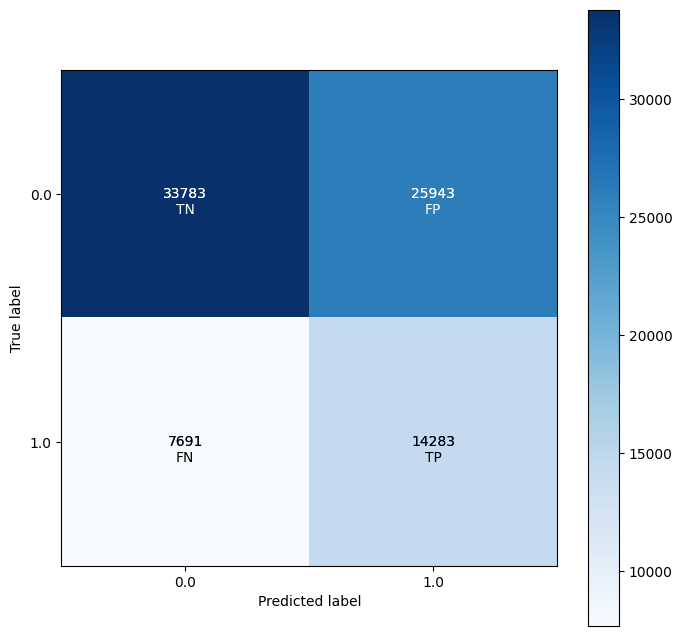

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

confmat = confusion_matrix(y_true=y_test, y_pred=preds)
disp = ConfusionMatrixDisplay(confusion_matrix=confmat,
                               display_labels=Pipe.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
im = disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

# add annotations to each square
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(j, i, f"\n{confmat[i, j]:d}\n"
                       f"{'TN' if i == j and i==0 else 'TP' if i== j and i ==1 else 'FP' if j > i else 'FN'}",
                ha="center", va="center", color="white" if confmat[i, j] > confmat.max() / 2 else "black")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, \
                            recall_score, f1_score, \
                            roc_auc_score, roc_curve, \
                            confusion_matrix , auc
fpr, tpr, threshold = roc_curve(y_test['target'],pred_proba)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
print("Score: "+ str(roc_auc))
plt.show()

# average precision

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming you have true labels and predicted probabilities

# Compute precision and recall values
precision, recall, _ = precision_recall_curve(y_test['target'],pred_proba)

# Calculate average precision
ap = average_precision_score(y_test['target'],pred_proba)

# Plot precision-recall curve
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (AP={:.2f})'.format(ap))
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

print('Average Precision: {:.2f}'.format(ap))


# feature importance 

In [ ]:
categorical_encode_step = Pipe.named_steps['dealer'].named_transformers_['cat'].named_steps['onehot']
model_step = Pipe.named_steps['model']

onehot_columns = categorical_encode_step.get_feature_names()

importances = pd.Series(data=model_step.feature_importances_, index = np.array(numerical_features + list(onehot_columns)))
indices = np.argsort(importances)[::-1]
print("Feature ranking:")

for f in range(len(importances)):
    print("%d. feature %s (%f)" % (f + 1, importances.index[indices[f]], importances[indices[f]]))


plt.figure()
plt.title("Feature importances")
plt.bar(x=importances.index[indices], height=importances[indices],
        color="r", align="center");
plt.xticks(range(len(importances.index[indices])), importances.index[indices], rotation=45, ha="right")
plt.xlim([-1, X_train.shape[1]])
plt.xlabel('Features');
plt.ylabel('Importance');

plt.show()


# Trying Tuning the model

### Feature selection

In [ ]:
from sklearn.decomposition import PCA

# best_n_components = None
# best_average_precision = -np.inf

# # Try different combinations of n_components
# for n_components in range(10,110,10):
#     # Create a pipeline for feature selection and classification
#     Pipe = Pipeline([
#     ('preprocces',Preprocces()),
#     ('imputer',FullImputer())
#     ,('dealer',Dealer)
#     ,('pca', PCA(n_components=10))
#     ,('model',LGBMClassifier(random_state=42,n_jobs=-1))
# ])


#     # Train the pipeline
#     Pipe.fit(X_train,y_train['target'])

#     # Get predicted probabilities on the test set
#     y_pred_proba = Pipe.predict_proba(X_test)[:, 1]

#     # Calculate average precision score
#     average_precision = average_precision_score(y_test['target'],y_pred_proba)

#     # Update the best n_components if a higher average precision is achieved
#     if average_precision > best_average_precision:
#         best_n_components = n_components
#         best_average_precision = average_precision

# print("Best n_components:", best_n_components)
# print("Best average precision:", best_average_precision)

### random search for Gradient boosting on roc curve

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.model_selection import ParameterSampler
# # define the hyperparameters to search over
# hyperparameters = {
#     'model__learning_rate': [0.01, 0.05, 0.1, 0.2],  # learning rate for the GradientBoostingClassifier
#     'model__n_estimators': [50, 100, 200, 400],  # number of trees for the GradientBoostingClassifier
#     'model__max_depth': [3, 4, 5, 6],  # maximum depth of each tree for the GradientBoostingClassifier
#     'model__min_samples_split': [2, 4, 8],  # minimum number of samples required to split an internal node
#     'model__min_samples_leaf': [1, 2, 4]  # minimum number of samples required to be at a leaf node
# }
# random_search = RandomizedSearchCV(Pipe, hyperparameters,n_iter=400, cv=2, n_jobs=-1,scoring='roc_auc',verbose=1)
# random_search.fit(X_trainAll,y_trainAll['target'])

# best = random_search.best_estimator_
# joblib.dump(Pipe, 'pickles/diffmodel/Lightgbm_pipe.pickle') 

### random search for Lightgbm

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import make_scorer, average_precision_score
# from scipy.stats import randint as sp_randint

# # Define the pipeline

# # Define the parameter grid for random search
# param_grid = {
#     'model__n_estimators': [100, 200, 300,500,600,700,800],  # Number of boosting iterations
#     'model__learning_rate': [0.01, 0.1, 0.3],  # Learning rate for each boosting iteration
#     'model__max_depth': [3, 5, -1],  # Maximum tree depth (-1 means no limit)
#     'model__num_leaves': [15, 31, 63,50],  # Maximum number of leaves in one tree
# }

# # Define the average precision scorer
# avg_precision_scorer = make_scorer(average_precision_score, greater_is_better=True)

# # Perform random search with 100 iterations using average precision as the scoring metric
# random_search = RandomizedSearchCV(Pipe, param_distributions=param_grid, n_iter=100, scoring=avg_precision_scorer, random_state=42,cv=3,verbose=1)
# random_search.fit(X_train,y_train['target'])

# # Get the best estimator and its average precision score
# best_estimator = random_search.best_estimator_
# best_avg_precision = random_search.best_score_

# # Print the best estimator and its average precision score
# print("Best Estimator:", best_estimator)
# print("Best Average Precision Score:", best_avg_precision)


### pickle best estimator 

In [ ]:
# joblib.dump(best_estimator, 'pickles/try/lastone.pickle') 

### random search on average precision

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import make_scorer, average_precision_score
# from scipy.stats import randint as sp_randint

# # Define the pipeline

# # Define the parameter grid for random search
# param_grid = {
#     'model__n_estimators': sp_randint(100, 1000),
#     'model__learning_rate': [0.1, 0.01, 0.001],
#     'model__max_depth': sp_randint(3, 10)
# }

# # Define the average precision scorer
# avg_precision_scorer = make_scorer(average_precision_score, greater_is_better=True)

# # Perform random search with 100 iterations using average precision as the scoring metric
# random_search = RandomizedSearchCV(Pipe, param_distributions=param_grid, n_iter=2, scoring=avg_precision_scorer, random_state=42)
# random_search.fit(X_train,y_train['target'])

# # Get the best estimator and its average precision score
# best_estimator = random_search.best_estimator_
# best_avg_precision = random_search.best_score_

# # Print the best estimator and its average precision score
# print("Best Estimator:", best_estimator)
# print("Best Average Precision Score:", best_avg_precision)


### another approach while keep track of precision recall curve

In [ ]:
# from sklearn.model_selection import ParameterSampler
# from tqdm.notebook import tqdm
# from sklearn.metrics import precision_recall_curve, f1_score
# # define the hyperparameters to search over

# hyperparameters = {
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],  # learning rate for the GradientBoostingClassifier
#     'n_estimators': [50, 100, 200, 400],  # number of trees for the GradientBoostingClassifier
#     'max_depth': [3, 4, 5, 6],  # maximum depth of each tree for the GradientBoostingClassifier
#     'min_samples_split': [2, 4, 8],  # minimum number of samples required to split an internal node
#     'min_samples_leaf': [1, 2, 4]  # minimum number of samples required to be at a leaf node
# }
# best_recall = .70
# best_perc = .3
# best_Pipe = None
# for x in ParameterSampler(hyperparameters,100):
#     clf = GradientBoostingClassifier(**x)
#     Pipe = Pipeline([
#     ('preprocces',Preprocces()),
#     ('imputer',FullImputer())
#     ,('dealer',Dealer)
#     ,('model',clf)
# ])
#     Pipe.fit(X_train,y_train['target'])

#     pred_proba = Pipe.predict_proba(X_test)[:, 1]
#     precisions, recalls, thresholds = precision_recall_curve(y_test['target'], pred_proba)
#     precisions = precisions[:-1]
#     recalls = recalls[:-1]
# # f1_scores = 2*(precision*recall)/(precision + recall)
#     min_index = [i for i, rec in enumerate(recalls) if rec >= best_recall][-1]
#     recall = recalls[min_index]
#     precision = precisions[min_index]
#     threshold = thresholds[min_index]
#     if precision> best_perc:
#         best_Pipe = Pipe
#         best_perc = precision
#         params = Pipe.named_steps['model']
#         print(f'the best we got with precision {best_perc} and recall{recall} and threshold {threshold}and with paramters{params}')

# Get categories values for Api validation

In [ ]:
# categories_values = {}

# for col in [x for x in X_train.columns if x not in ['observation_id', 'Date', 'Longitude', 'Latitude','Part of a policing operation']]:
    
#     unique_values = X_train[col].unique().tolist()
#     categories_values[col] = unique_values
    

# with open('pickles/categories_values.json', 'w') as fh:
#     json.dump(categories_values, fh)

# save pickles

In [ ]:
# # saving the pipeline and columns and dtypes and boundries
# boudries_of_numric = {
#     col: {
#         'max': df_model[col].max(),
#         'min': df_model[col].min()
#     }
#     for col in ['Longitude','Latitude']
# }
# boudries_of_numric
# with open('pickles/boundriesOfNumeric.json', 'w') as fh:
#     json.dump(boudries_of_numric, fh)

# with open('pickles/columns.json', 'w') as fh:
#     json.dump(X_train.columns.tolist(), fh)
# with open('pickles/dtypes.pickle', 'wb') as fh:
#     pickle.dump(X_train.dtypes, fh)
# joblib.dump(best_estimator, 'pickles/try/bestlight.pickle') 

# trying on single raw with unknown value for validation

In [ ]:
# tr = X_test.iloc[[0]].copy()
# tr['station'] = 'main'


# pred_proba = Pipe.predict_proba(tr)[0, 1]
# pred_proba
# preds = [1 if pred > threshold else 0 for pred in pred_proba ]